# Multilayer perceptron and backpropagation

### A neural network in NumPy, with every gradient derived

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com) ·
[all notebooks](../../CURRICULUM.md)

---

| | |
|---|---|
| **What you will learn** | What backpropagation actually computes, how to derive every gradient by hand, how to check them numerically, and how to train a working network in NumPy alone |
| **You should already know** | [The perceptron](../01-the-perceptron/), the chain rule |
| **Dataset** | UCI Dry Bean (13,611 × 16, 7 classes) |
| **Runtime** | About two minutes on a laptop CPU |
| **Next** | [07-03 The same net in PyTorch](../03-the-same-net-in-pytorch/) |

---

## 1. The problem backpropagation solves

The [perceptron](../01-the-perceptron/) ended on a wall. A hidden layer can
rebuild the input space so that a line separates the classes, but the
perceptron rule cannot train one, because it needs each unit's error, and
**nobody tells you what a hidden unit should have output**.

Backpropagation answers that. It is not a learning algorithm; it is a way of
computing derivatives. Gradient descent is still doing the learning. Backprop
just works out, efficiently, how much each weight contributed to the final error.

The insight is the chain rule applied in the right order. To know how a
first-layer weight affects the loss, you multiply together how it affects its
own unit, how that unit affects the next layer, and how that affects the loss.
Compute those factors **from the output backwards** and every one gets reused.
Compute them forwards and you redo the same work for every weight.

In [1]:
import sys
import pathlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
            if (p / "toolkit").is_dir())
sys.path.insert(0, str(ROOT))

from toolkit import datasets, style

style.use()
FIG = pathlib.Path("figures")
SEED = 0

## 2. The maths, one layer at a time

The network: input $x$, one hidden layer with ReLU, a softmax output, and cross
entropy loss.

**Forward**

$$z_1 = x W_1 + b_1 \qquad a_1 = \max(0, z_1) \qquad z_2 = a_1 W_2 + b_2 \qquad \hat{p} = \text{softmax}(z_2)$$

Follow one bean through that line. $x$ is its 16 measurements. $W_1$ and $b_1$ are
the first layer's weights and biases, so $z_1$ is what the hidden units compute
before any activation. $a_1$ is the same thing after ReLU has flattened every
negative value to zero. $W_2$ and $b_2$ send those hidden values on to seven
output numbers, $z_2$, one per bean variety. Softmax then squashes those seven
numbers into probabilities that add to 1, giving $\hat{p}$.

$$L = -\sum_c y_c \log \hat{p}_c$$

$L$ is the loss for that bean, $c$ runs over the seven varieties, and $y_c$ is 1
for the true variety and 0 for the rest. So the sum collapses to the negative log
of the probability the network gave the right answer. Confident and right costs
almost nothing; confident and wrong costs a lot.

**Backward.** Start at the end. Softmax paired with cross entropy gives a result
so clean it looks like a mistake:

$$\frac{\partial L}{\partial z_2} = \hat{p} - y$$

Prediction minus truth, the same expression that appeared in
[linear regression](../../02-regression/01-linear-regression/) and
[logistic regression](../../03-classification/01-logistic-regression/). The
messy softmax derivative and the messy log derivative cancel exactly.

From there each step is mechanical. Write $\delta_2 = \hat{p} - y$ for the error
arriving at the output layer:

$$\frac{\partial L}{\partial W_2} = a_1^\top \delta_2 \qquad \frac{\partial L}{\partial b_2} = \sum \delta_2$$

$$\delta_1 = (\delta_2 W_2^\top) \odot \mathbb{1}[z_1 > 0] \qquad \frac{\partial L}{\partial W_1} = x^\top \delta_1 \qquad \frac{\partial L}{\partial b_1} = \sum \delta_1$$

Two symbols in that second line. $\odot$ multiplies entry by entry, and
$\mathbb{1}[z_1 > 0]$ is a matrix of ones and zeros, one wherever the hidden unit
was positive before ReLU and zero wherever it was not. So $\delta_1$ is the error
pushed back through $W_2$ and then blanked out at every hidden unit that ReLU had
switched off.

The pattern repeats for any depth: push the error back through the weights, then
multiply by the activation's derivative. ReLU's derivative is 1 where the input
was positive and 0 elsewhere, which is why that term is just a mask.

## 3. From scratch

In [2]:
def softmax(z):
    # Subtract the row max before exponentiating. Mathematically a no-op, and the
    # difference between a working network and a wall of nan.
    shifted = z - z.max(axis=1, keepdims=True)
    e = np.exp(shifted)
    return e / e.sum(axis=1, keepdims=True)


class NeuralNetwork:
    """One hidden layer, ReLU, softmax output, trained by mini-batch SGD."""

    def __init__(self, n_hidden=64, learning_rate=0.1, n_epochs=60, batch_size=128, seed=0):
        self.n_hidden = n_hidden
        self.learning_rate = learning_rate
        self.n_epochs = n_epochs
        self.batch_size = batch_size
        self.seed = seed

    def _init_weights(self, n_features, n_classes):
        rng = np.random.default_rng(self.seed)
        # He initialisation: variance 2/fan_in keeps ReLU activations from
        # shrinking toward zero as they pass through layers.
        self.W1 = rng.normal(0, np.sqrt(2.0 / n_features), (n_features, self.n_hidden))
        self.b1 = np.zeros(self.n_hidden)
        self.W2 = rng.normal(0, np.sqrt(2.0 / self.n_hidden), (self.n_hidden, n_classes))
        self.b2 = np.zeros(n_classes)

    def _forward(self, X):
        z1 = X @ self.W1 + self.b1
        a1 = np.maximum(0.0, z1)
        z2 = a1 @ self.W2 + self.b2
        return z1, a1, z2, softmax(z2)

    def _backward(self, X, Y, z1, a1, p):
        n = len(X)
        d2 = (p - Y) / n                        # softmax + cross entropy, combined
        gW2 = a1.T @ d2
        gb2 = d2.sum(axis=0)

        d1 = (d2 @ self.W2.T) * (z1 > 0)        # ReLU derivative is a mask
        gW1 = X.T @ d1
        gb1 = d1.sum(axis=0)
        return gW1, gb1, gW2, gb2

    def fit(self, X, Y, X_val=None, Y_val=None):
        X, Y = np.asarray(X, float), np.asarray(Y, float)
        self._init_weights(X.shape[1], Y.shape[1])
        rng = np.random.default_rng(self.seed)
        self.train_loss_, self.val_loss_, self.val_acc_ = [], [], []

        for _ in range(self.n_epochs):
            order = rng.permutation(len(X))
            for start in range(0, len(X), self.batch_size):
                batch = order[start:start + self.batch_size]
                xb, yb = X[batch], Y[batch]

                z1, a1, _, p = self._forward(xb)
                gW1, gb1, gW2, gb2 = self._backward(xb, yb, z1, a1, p)

                self.W1 -= self.learning_rate * gW1
                self.b1 -= self.learning_rate * gb1
                self.W2 -= self.learning_rate * gW2
                self.b2 -= self.learning_rate * gb2

            self.train_loss_.append(self.loss(X, Y))
            if X_val is not None:
                self.val_loss_.append(self.loss(X_val, Y_val))
                self.val_acc_.append((self.predict(X_val) == Y_val.argmax(axis=1)).mean())
        return self

    def loss(self, X, Y):
        p = self._forward(np.asarray(X, float))[3]
        return float(-np.mean(np.sum(Y * np.log(p + 1e-12), axis=1)))

    def predict(self, X):
        return self._forward(np.asarray(X, float))[3].argmax(axis=1)


print("network defined: input -> 64 ReLU units -> softmax")

network defined: input -> 64 ReLU units -> softmax


### Check the gradients before trusting them

A backprop bug does not crash. It trains slightly worse, and you never find out.
The only reliable defence is to compare the analytic gradients against numerical
estimates:

$$\frac{\partial L}{\partial w} \approx \frac{L(w + \varepsilon) - L(w - \varepsilon)}{2\varepsilon}$$

Take one weight $w$, nudge it up by a tiny amount $\varepsilon$ and measure the
loss, nudge it down by the same amount and measure again, then divide the change
by the distance moved. That is the gradient by definition, computed with no
derivation to get wrong. Slow, and completely impractical for training. As a
one-off test it is decisive.

Each parameter costs two full forward passes, so I **sample** rather than check
everything: up to twelve entries per tensor, drawn at random. The printout says
how many that came to out of how many exist. Sampling is the usual practice and
it is enough here, because a wrong derivation is wrong across a whole tensor
rather than in one entry of it.

In [3]:
rng = np.random.default_rng(SEED)
X_toy = rng.normal(size=(24, 5))
Y_toy = np.eye(3)[rng.integers(0, 3, 24)]

net = NeuralNetwork(n_hidden=7, seed=SEED)
net._init_weights(5, 3)

z1, a1, _, p = net._forward(X_toy)
analytic = net._backward(X_toy, Y_toy, z1, a1, p)

epsilon = 1e-6
worst = 0.0
n_checked = n_total = 0
for name, matrix, grad in [("W1", net.W1, analytic[0]), ("b1", net.b1, analytic[1]),
                           ("W2", net.W2, analytic[2]), ("b2", net.b2, analytic[3])]:
    flat = matrix.reshape(-1)
    checks = rng.choice(flat.size, min(12, flat.size), replace=False)
    n_checked += len(checks)
    n_total += flat.size
    diffs = []
    for i in checks:
        original = flat[i]
        flat[i] = original + epsilon
        up = net.loss(X_toy, Y_toy)
        flat[i] = original - epsilon
        down = net.loss(X_toy, Y_toy)
        flat[i] = original
        numeric = (up - down) / (2 * epsilon)
        diffs.append(abs(numeric - grad.reshape(-1)[i]))
    worst = max(worst, max(diffs))
    print(f"{name}: {len(checks):>2} of {flat.size:>2} entries sampled, "
          f"largest gap between analytic and numerical gradient = {max(diffs):.3e}")

print(f"\nsampled {n_checked} of the {n_total} parameters")
print(f"worst overall: {worst:.3e}  ->  {'the derivation is correct' if worst < 1e-6 else 'CHECK THE MATHS'}")

W1: 12 of 35 entries sampled, largest gap between analytic and numerical gradient = 1.455e-10
b1:  7 of  7 entries sampled, largest gap between analytic and numerical gradient = 1.947e-10
W2: 12 of 21 entries sampled, largest gap between analytic and numerical gradient = 1.915e-10
b2:  3 of  3 entries sampled, largest gap between analytic and numerical gradient = 7.337e-11

sampled 34 of the 66 parameters
worst overall: 1.947e-10  ->  the derivation is correct


## 4. Training it

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelBinarizer

X_bean, y_bean = datasets.dry_bean()
binariser = LabelBinarizer().fit(y_bean)

X_train, X_test, y_train, y_test = train_test_split(
    X_bean.values, y_bean.values, test_size=0.25, stratify=y_bean, random_state=SEED)

scaler = StandardScaler().fit(X_train)
X_train_s, X_test_s = scaler.transform(X_train), scaler.transform(X_test)
Y_train, Y_test = binariser.transform(y_train), binariser.transform(y_test)

net = NeuralNetwork(n_hidden=64, learning_rate=0.1, n_epochs=60, seed=SEED)
net.fit(X_train_s, Y_train, X_test_s, Y_test)

print(f"final training loss   : {net.train_loss_[-1]:.4f}")
print(f"final held-out loss   : {net.val_loss_[-1]:.4f}")
print(f"final held-out accuracy: {net.val_acc_[-1]:.4f}")

final training loss   : 0.1850
final held-out loss   : 0.1889
final held-out accuracy: 0.9306


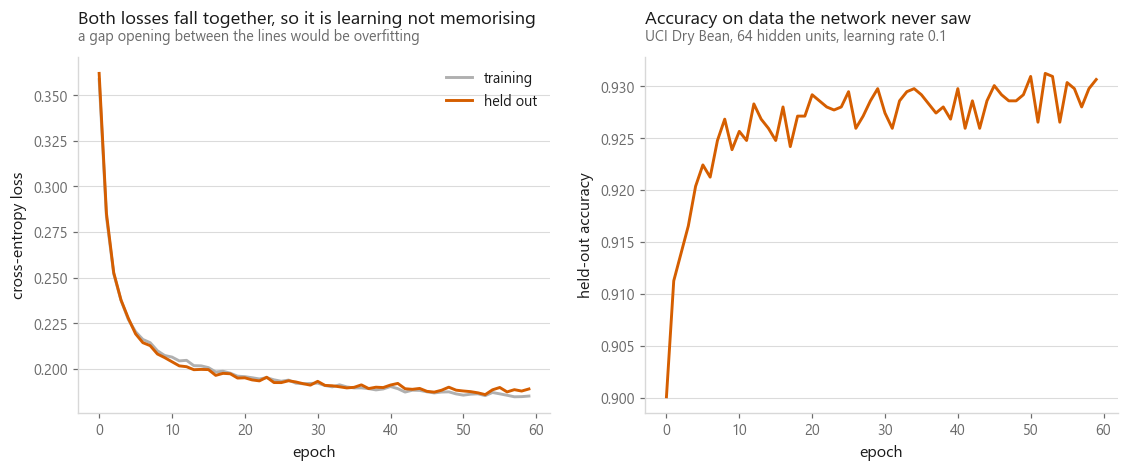

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12.2, 4.2))

axes[0].plot(net.train_loss_, color=style.NEUTRAL, label="training")
axes[0].plot(net.val_loss_, color=style.HIGHLIGHT, label="held out")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("cross-entropy loss")
axes[0].legend()
style.title(axes[0], "Both losses fall together, so it is learning not memorising",
            "a gap opening between the lines would be overfitting")

axes[1].plot(net.val_acc_, color=style.HIGHLIGHT)
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("held-out accuracy")
style.title(axes[1], "Accuracy on data the network never saw",
            "UCI Dry Bean, 64 hidden units, learning rate 0.1")

style.save(fig, FIG / "fig-01-training.png")

### How wide does the hidden layer need to be?

 hidden units  held-out accuracy  parameters
            2             0.8099          55
            4             0.9151         103
            8             0.9254         199
           16             0.9248         391
           32             0.9289         775
           64             0.9268        1543
          128             0.9286        3079
          256             0.9251        6151

over widths 8 to 256, held-out accuracy runs 0.9248 to 0.9289, a spread of 0.0041


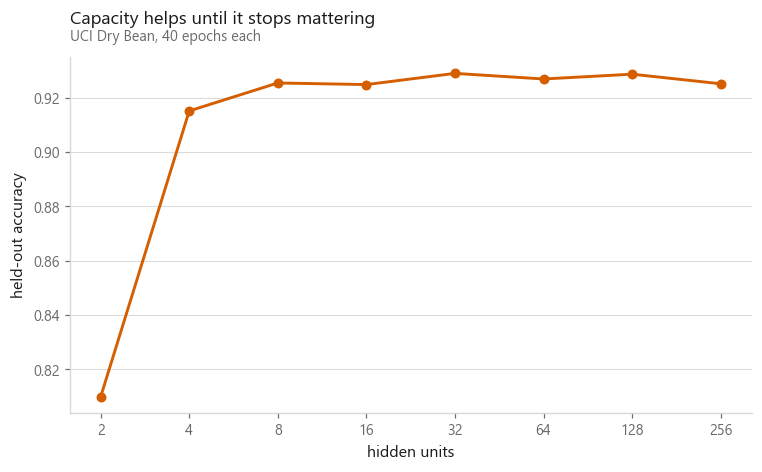

In [6]:
widths = [2, 4, 8, 16, 32, 64, 128, 256]
records = []
for width in widths:
    trained = NeuralNetwork(n_hidden=width, learning_rate=0.1, n_epochs=40, seed=SEED)
    trained.fit(X_train_s, Y_train, X_test_s, Y_test)
    n_params = (X_train_s.shape[1] * width + width) + (width * Y_train.shape[1] + Y_train.shape[1])
    records.append({"hidden units": width,
                    "held-out accuracy": trained.val_acc_[-1],
                    "parameters": n_params})
widths_frame = pd.DataFrame(records)

fig, ax = plt.subplots(figsize=(8.0, 4.2))
ax.plot(widths_frame["hidden units"], widths_frame["held-out accuracy"],
        marker=style.MARKERS[0], color=style.HIGHLIGHT)
ax.set_xscale("log", base=2)
ax.set_xticks(widths, [str(w) for w in widths])
ax.set_xlabel("hidden units")
ax.set_ylabel("held-out accuracy")
style.title(ax, "Capacity helps until it stops mattering",
            "UCI Dry Bean, 40 epochs each")
style.save(fig, FIG / "fig-02-width.png")

print(widths_frame.round(4).to_string(index=False))

# How much does held-out accuracy move for a change that should barely matter?
# This is a cheap noise floor for the comparison in section 5.
settled = widths_frame[widths_frame["hidden units"] >= 8]["held-out accuracy"]
print(f"\nover widths 8 to 256, held-out accuracy runs {settled.min():.4f} to "
      f"{settled.max():.4f}, a spread of {settled.max() - settled.min():.4f}")

## 5. Against everything else in the book

A neural network is not automatically the strongest model. On tabular data it
usually is not.

  our NumPy network     : 0.9306
  gradient boosting     : 0.9257
  random forest         : 0.9251
  logistic regression   : 0.9245

top two differ by                    : 0.0050
spread from changing width alone     : 0.0041


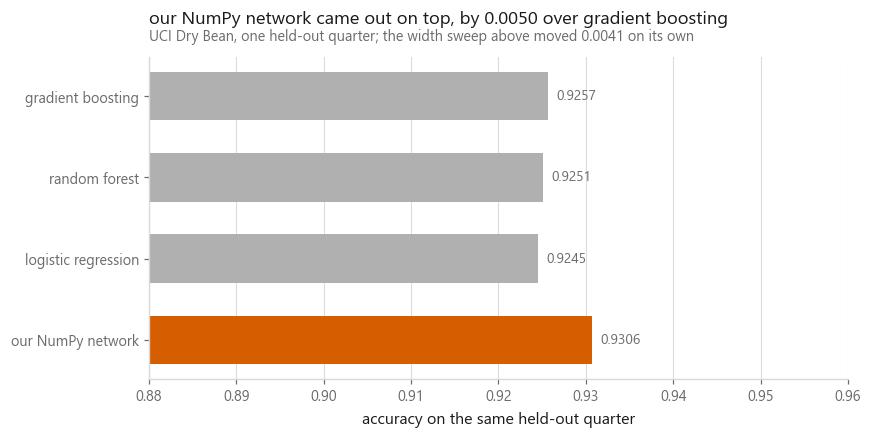

In [7]:
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline

rivals = {
    "logistic regression": make_pipeline(StandardScaler(), LogisticRegression(max_iter=3000)),
    "random forest": RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=SEED),
    "gradient boosting": HistGradientBoostingClassifier(random_state=SEED),
}
scores = {"our NumPy network": net.val_acc_[-1]}
for name, estimator in rivals.items():
    estimator.fit(X_train, y_train)
    scores[name] = estimator.score(X_test, y_test)

fig, ax = plt.subplots(figsize=(8.2, 3.8))
names = list(scores)
colours = [style.HIGHLIGHT] + [style.NEUTRAL] * (len(names) - 1)
ax.barh(names, [scores[n] for n in names], color=colours, height=0.6)
for i, n in enumerate(names):
    ax.text(scores[n] + 0.001, i, f"{scores[n]:.4f}", va="center", fontsize=9, color=style.MUTED)
ax.set_xlim(0.88, 0.96)
ax.set_xlabel("accuracy on the same held-out quarter")
ax.grid(axis="y", visible=False); ax.grid(axis="x", visible=True)
ranked = sorted(scores.items(), key=lambda kv: -kv[1])
lead = ranked[0][1] - ranked[1][1]
style.title(ax,
            f"{ranked[0][0]} came out on top, by {lead:.4f} over {ranked[1][0]}",
            f"UCI Dry Bean, one held-out quarter; the width sweep above moved "
            f"{settled.max() - settled.min():.4f} on its own")
style.save(fig, FIG / "fig-03-comparison.png")

for name, score in ranked:
    print(f"  {name:<22}: {score:.4f}")
print(f"\ntop two differ by                    : {lead:.4f}")
print(f"spread from changing width alone     : {settled.max() - settled.min():.4f}")

About seventy lines of NumPy came out **ahead of scikit-learn's boosted trees**,
which was not what I expected to be writing here.

Before celebrating, read the gap properly. The network scored 0.9306 and gradient
boosting 0.9257, a difference of 0.0049 on a **single** held-out quarter.

The width sweep two cells ago is the cheapest available check on whether 0.0049
means anything. Between 8 and 256 hidden units, a change that the same sweep
shows barely matters, held-out accuracy still wandered from 0.9248 to 0.9289, a
spread of 0.0041. That is the same size as the gap I would be claiming as a win,
produced by a knob that does nothing.

So the honest reading is **a tie measured badly**, not a win. A single split is a
sample of size one, and I would not defend an ordering built on it. If the
ordering mattered I would rerun all four models under repeated cross-validation
and quote the spread.

What the result does establish is that a from-scratch implementation is genuinely
competitive rather than a toy. That is worth something.

It also does not change the practical advice. Gradient boosting needed one line
and no tuning; the network needed a derivation, an initialisation scheme, a
learning rate, a width, and an epoch count. Neural networks earn their keep where
the input has **structure a tree cannot exploit**: the grid of an image, the
order of a sequence. That is [Part 8](../../08-computer-vision/) and
[Part 9](../../09-sequences-and-language/), where the gap stops being noise.

## Cheat sheet

| | |
|---|---|
| **Backprop is** | A way to compute derivatives, not a learning algorithm. Gradient descent does the learning |
| **The key simplification** | Softmax with cross entropy gives $\partial L/\partial z = \hat{p} - y$. Never derive them separately |
| **Numerical stability** | Subtract the row max before `exp`, and add `1e-12` before `log` |
| **Initialisation** | He (variance $2/\text{fan-in}$) for ReLU, Xavier for tanh. Zeros make every unit identical forever |
| **Always** | Gradient-check a new implementation once. A wrong gradient trains quietly and badly |
| **Scaling needed** | Yes. Unscaled inputs make the loss surface long and thin, and gradient descent crawls |

## What to remember

1. Backprop is the chain rule applied output-first so intermediate results get reused.
2. $\delta_2 = \hat{p} - y$, the same "prediction minus truth" as every earlier chapter.
3. ReLU's derivative is a mask: 1 where the input was positive, 0 elsewhere.
4. Gradient-check before you trust a network.
5. Wider helps until it stops helping.
6. On tabular data a neural network is competitive with boosted trees, and costs
   far more decisions to get there. My 0.0049 lead over gradient boosting is the
   same size as the 0.0041 the width sweep produced from a knob that does not
   matter, so it is a tie. Judge close results on cross-validation, not one split.

---

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com)

Next: [07-03 The same net in PyTorch](../03-the-same-net-in-pytorch/) ·
Back to [the curriculum](../../CURRICULUM.md)

`#DeepLearning` `#Backpropagation` `#NeuralNetwork` `#NumPy` `#MachineLearning`
`#Python` `#MLTutorial` `#GradientDescent` `#LearnMachineLearning` `#AI`